# ⚙️ WBS Tahap 4: Modeling & Imbalance Handling Experiments

**Proyek:** Analisis Sentimen Ulasan Destinasi Wisata untuk Pengambilan Kebijakan Promosi Wisata pada Dinas Pariwisata dan Kebudayaan Kabupaten Garut  
**Objektif:** Mengembangkan, membandingkan, dan memilih model klasifikasi Linear Support Vector Machine (Linear SVM) terbaik untuk menangani dataset ulasan pariwisata yang mengalami ketimpangan kelas (*class imbalance*).

---

### 📋 Tahapan Aktivitas WBS Terkait:

1. **Pembagian Data (*Stratified Train-Test Split* 80:20)**
   * Membagi dataset berlabel (~17.923 ulasan) menjadi 80% *Training Set* dan 20% *Test Set*.
   * Menggunakan strategi *stratified split* untuk mempertahankan proporsi kelas alami (*Positif: 86,78%*, *Netral: 4,57%*, *Negatif: 8,65%*) di kedua subset data.

2. **Pencegahan Kebocoran Data (*Data Leakage Prevention*) pada Fitur TF-IDF**
   * Melakukan proses pembentukan kamus kata (*fit*) menggunakan `TfidfVectorizer` **hanya pada Training Set (80%)**.
   * Mentransformasikan *Test Set (20%)* secara terisolasi tanpa menyentuh *vocabulary* uji untuk menjaga objektivitas evaluasi.

3. **Eksperimen Komparasi 5 Skenario *Class Imbalance Handling***
   Menguji 5 pendekatan penanganan ketimpangan data secara independen pada *Training Set*:
   * **Skenario 1 (Baseline / No Handling):** Pelatihan model SVM polos tanpa intervensi penyeimbangan.
   * **Skenario 2 (Class Weight Balanced):** Pendekatan *algorithm-level* menggunakan pembobotan penalti (*cost-sensitive learning*) pada fungsi *loss* SVM.
   * **Skenario 3 (Oversampling / ROS):** Pendekatan *data-level oversampling* dengan menduplikasi sampel minoritas secara acak.
   * **Skenario 4 (Undersampling / RUS):** Pendekatan *data-level undersampling* dengan memotong sampel kelas mayoritas.
   * **Skenario 5 (SMOTE):** Pendekatan *synthetic oversampling* dengan membentuk sampel sintetis berbasis *k-Nearest Neighbors* di ruang fitur TF-IDF.

4. **Evaluasi dan Pemilihan Model Utama (*Best Model Selection*)**
   * Menguji kelima model pada *Test Set* murni yang tidak tersentuh (*unseen data*).
   * Menganalisis *Macro F1-Score* sebagai metrik utama dan *Balanced Accuracy* sebagai metrik pendukung untuk memilih teknik paling optimal.
   * Menetapkan **Skenario 2 (Class Weight Balanced)** sebagai model utama karena menghasilkan *Macro F1-Score* tertinggi (**0,6356**) tanpa membuang informasi asli (*RUS*) maupun menambah *noise* sintetis (*SMOTE/ROS*).

5. **Serialisasi Model dan Vectorizer**
   * Menyimpan artefak model terpilih (`models/svm_model.joblib`) dan matriks ekstraksi fitur (`models/tfidf_vectorizer.joblib`) untuk kebutuhan inferensi *pipeline* dan aplikasi *dashboard*.

6. **Analisis Kesalahan (*Error Analysis*) & Interpretasi Matriks**
   * Menganalisis *Confusion Matrix* kelima skenario untuk mengidentifikasi pola salah prediksi, khususnya pada ulasan *Netral* (rating 3 bintang).

---

### 📦 Output Tahap Ini:
* **Artefak Ter-serialisasi:** `models/svm_model.joblib` dan `models/tfidf_vectorizer.joblib`.
* **Dataset Hasil Eksperimen:** `data/final/imbalance_experiment_comparison.csv` dan `data/final/error_analysis.csv`.
* **Visualisasi Komparatif:** 
  * Grafik bar komparasi metrik (`data/final/imbalance_experiments_comparison.png`).
  * Grid matriks konfusi 5 skenario (`data/final/all_scenarios_confusion_matrices.png`).
* **Dokumentasi Performa:** File rekapitulasi `data/final/classification_report.txt` dan metadata eksperimen `data/final/experiment_metadata.json`.

In [8]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

import sys
import os
import warnings
import joblib
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

CURRENT_DIR = Path.cwd()
ROOT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Impor pustaka untuk Imbalance Handling
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

from config import settings
from sentiment.labeling import apply_sentiment_labeling

print(f"✅ Root Project Directory: {ROOT_DIR}")
print("Pustaka pemodelan Scikit-Learn Linear SVM & Imbalance Handling siap digunakan.")

✅ Root Project Directory: /Users/macbook/Garut-Tourism-Reccomendation
Pustaka pemodelan Scikit-Learn Linear SVM & Imbalance Handling siap digunakan.


Pada sel ini, dilakukan konfigurasi lingkungan kerja Jupyter Notebook, pengaturan direktori root proyek secara otomatis, mengabaikan warning yang tidak diperlukan, serta mengimpor seluruh pustaka pendukung untuk manipulasi data, ekstraksi fitur TF-IDF, pemodelan Linear SVM, teknik penanganan class imbalance, dan metrik evaluasi.

In [9]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

import sys
import os
import warnings
import joblib
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

CURRENT_DIR = Path.cwd()
ROOT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Pustaka Handling Class Imbalance
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

from config import settings

print(f"✅ Root Project Directory: {ROOT_DIR}")
print("Pustaka pemodelan Scikit-Learn Linear SVM & Imbalance Handling siap digunakan.")

✅ Root Project Directory: /Users/macbook/Garut-Tourism-Reccomendation
Pustaka pemodelan Scikit-Learn Linear SVM & Imbalance Handling siap digunakan.


Memuat dataset hasil pelabelan sentimen ulasan wisata Garut (labeled_reviews.csv). Sel ini memisahkan fitur teks ulasan (cleaned_text) dan label sentimen target (sentiment_label) dengan skema pemetaan numerik standar:

0: Positif
1: Netral
2: Negatif

In [10]:
DATA_PATH = settings.FINAL_DATA_DIR / "labeled_reviews.csv"
df = pd.read_csv(DATA_PATH)

X = df["cleaned_text"].astype(str).tolist()
y = df["sentiment_label"].astype(int).tolist()

sentiment_names = {0: "Positif", 1: "Netral", 2: "Negatif"}

print(f"Total Dataset Terpilih: {len(df):,} ulasan")
print("Distribusi Sentimen Asli:")
for label_idx, count in pd.Series(y).value_counts().sort_index().items():
    pct = (count / len(y)) * 100
    print(f"  - Kelas {label_idx} ({sentiment_names[label_idx]}): {count:,} ulasan ({pct:.2f}%)")

Total Dataset Terpilih: 17,923 ulasan
Distribusi Sentimen Asli:
  - Kelas 0 (Positif): 1,551 ulasan (8.65%)
  - Kelas 1 (Netral): 819 ulasan (4.57%)
  - Kelas 2 (Negatif): 15,553 ulasan (86.78%)


Membagi dataset menjadi 80% Training Set dan 20% Test Set menggunakan metode Stratified Sampling. Pendekatan ini menjamin bahwa proporsi ketimpangan kelas alami pada populasi data tetap terjaga secara identik di kedua subset data tanpa menimbulkan data leakage.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=getattr(settings, "TEST_SIZE", 0.2),
    stratify=y,
    random_state=getattr(settings, "RANDOM_STATE", 42)
)

# Dokumentasi Distribusi Stratifikasi
y_series = pd.Series(y)
y_train_series = pd.Series(y_train)
y_test_series = pd.Series(y_test)

train_dist = y_train_series.value_counts().sort_index()
test_dist = y_test_series.value_counts().sort_index()
total_dist = y_series.value_counts().sort_index()

tabel_split = pd.DataFrame({
    "Kelas Sentimen": [f"{sentiment_names[i]} ({i})" for i in total_dist.index],
    "Total Sampel": [f"{total_dist[i]:,} ({total_dist[i]/len(y_series)*100:.2f}%)" for i in total_dist.index],
    "Training Set (80%)": [f"{train_dist[i]:,} ({train_dist[i]/len(y_train_series)*100:.2f}%)" for i in total_dist.index],
    "Test Set (20%)": [f"{test_dist[i]:,} ({test_dist[i]/len(y_test_series)*100:.2f}%)" for i in total_dist.index],
    "Rasio Stratifikasi": "Konsisten & Presisi"
})

print("=== TABEL DISTRIBUSI KELAS SETELAH STRATIFIED SPLIT (80:20) ===")
display(tabel_split)

=== TABEL DISTRIBUSI KELAS SETELAH STRATIFIED SPLIT (80:20) ===


,Kelas Sentimen,Total Sampel,Training Set (80%),Test Set (20%),Rasio Stratifikasi
0,Positif (0),"1,551 (8.65%)","1,241 (8.66%)",310 (8.65%),Konsisten & Presisi
1,Netral (1),819 (4.57%),655 (4.57%),164 (4.57%),Konsisten & Presisi
2,Negatif (2),"15,553 (86.78%)","12,442 (86.78%)","3,111 (86.78%)",Konsisten & Presisi


Melakukan ekstraksi fitur pembobotan TF-IDF (Term Frequency - Inverse Document Frequency) dengan aturan akademis ketat: pembentukan kamus kata (fit) hanya dilakukan pada Training Set (80%), sedangkan Test Set (20%) murni ditransformasikan (transform).

Konfigurasi ekstraksi fitur: max_features=10000, ngram_range=(1, 2).

In [12]:
tfidf = TfidfVectorizer(
    max_features=getattr(settings, "TFIDF_MAX_FEATURES", 10000),
    ngram_range=getattr(settings, "TFIDF_NGRAM_RANGE", (1, 2)),
    sublinear_tf=getattr(settings, "TFIDF_SUBLINEAR_TF", False)
)

# Fit & Transform hanya pada Training Set
X_train_tfidf = tfidf.fit_transform(X_train)
# Transformasi terisolasi pada Test Set
X_test_tfidf = tfidf.transform(X_test)

print(f"Dimensi Matriks TF-IDF Training Set : {X_train_tfidf.shape}")
print(f"Dimensi Matriks TF-IDF Test Set     : {X_test_tfidf.shape}")

# Penampung hasil eksperimen
exp_results = []
trained_models = {}

def evaluate_model(name, model, X_test_data, y_true):
    """Fungsi standar evaluasi model pada Test Set murni"""
    y_pred = model.predict(X_test_data)
    
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    p_cls, r_cls, f_cls, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2], zero_division=0)
    macro_p, macro_r, macro_f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    
    return {
        "Skenario Eksperimen": name,
        "Accuracy": f"{acc*100:.2f}%",
        "Balanced Acc": f"{bal_acc*100:.2f}%",
        "Positif F1 (0)": f"{f_cls[0]:.4f}",
        "Netral F1 (1)": f"{f_cls[1]:.4f}",
        "Negatif F1 (2)": f"{f_cls[2]:.4f}",
        "Macro Precision": f"{macro_p:.4f}",
        "Macro Recall": f"{macro_r:.4f}",
        "Macro F1-Score": f"{macro_f:.4f}",
        "raw_macro_f1": macro_f,
        "raw_bal_acc": bal_acc
    }

Dimensi Matriks TF-IDF Training Set : (14338, 10000)
Dimensi Matriks TF-IDF Test Set     : (3585, 10000)


Skenario 1: Melatih model Linear SVM murni tanpa teknik penyeimbangan data maupun pembobotan (class_weight=None). Skenario ini berfungsi sebagai kelompok kontrol (pembanding utama) untuk membuktikan dampak ketimpangan data terhadap kepekaan model dalam mendeteksi kelas minoritas (Netral dan Negatif).

In [13]:
print("=== EKSPERIMEN 1: BASELINE (NO HANDLING) ===")

model_baseline = LinearSVC(C=getattr(settings, "SVM_C", 0.2), class_weight=None, random_state=42, dual=False)
model_baseline.fit(X_train_tfidf, y_train)

res_1 = evaluate_model("1. Baseline (No Handling)", model_baseline, X_test_tfidf, y_test)
exp_results.append(res_1)
trained_models["1. Baseline (No Handling)"] = model_baseline

print(f"Accuracy: {res_1['Accuracy']} | Balanced Acc: {res_1['Balanced Acc']} | Macro F1: {res_1['Macro F1-Score']}")

=== EKSPERIMEN 1: BASELINE (NO HANDLING) ===
Accuracy: 90.43% | Balanced Acc: 50.51% | Macro F1: 0.5407


Skenario 2: Menggunakan pendekatan algorithm-level dengan menerapkan penalti bobot kesalahan berbalik dari proporsi kelas (cost-sensitive learning) menggunakan parameter class_weight='balanced'. Metode ini tidak mengubah jumlah baris data latih, melainkan memperbesar sanksi jika model salah mengklasifikasikan kelas minoritas.

In [14]:
print("=== EKSPERIMEN 2: CLASS WEIGHT BALANCED ===")

model_cw = LinearSVC(C=getattr(settings, "SVM_C", 0.2), class_weight="balanced", random_state=42, dual=False)
model_cw.fit(X_train_tfidf, y_train)

res_2 = evaluate_model("2. Class Weight Balanced", model_cw, X_test_tfidf, y_test)
exp_results.append(res_2)
trained_models["2. Class Weight Balanced"] = model_cw

print(f"Accuracy: {res_2['Accuracy']} | Balanced Acc: {res_2['Balanced Acc']} | Macro F1: {res_2['Macro F1-Score']}")

=== EKSPERIMEN 2: CLASS WEIGHT BALANCED ===
Accuracy: 90.40% | Balanced Acc: 62.08% | Macro F1: 0.6356


Skenario 3: Menggunakan teknik data-level oversampling (RandomOverSampler) dengan menduplikasi sampel ulasan pada kelas minoritas secara acak pada Training Set hingga jumlahnya setara dengan kelas mayoritas (Positif).

In [15]:
print("=== EKSPERIMEN 3: OVERSAMPLING (ROS) ===")

ros = RandomOverSampler(random_state=42)
X_tr_ros, y_tr_ros = ros.fit_resample(X_train_tfidf, y_train)

model_ros = LinearSVC(C=getattr(settings, "SVM_C", 0.2), class_weight=None, random_state=42, dual=False)
model_ros.fit(X_tr_ros, y_tr_ros)

res_3 = evaluate_model("3. Oversampling (ROS)", model_ros, X_test_tfidf, y_test)
exp_results.append(res_3)
trained_models["3. Oversampling (ROS)"] = model_ros

print(f"Jumlah Data Latih Setelah ROS: {X_tr_ros.shape[0]:,} baris")
print(f"Accuracy: {res_3['Accuracy']} | Balanced Acc: {res_3['Balanced Acc']} | Macro F1: {res_3['Macro F1-Score']}")

=== EKSPERIMEN 3: OVERSAMPLING (ROS) ===
Jumlah Data Latih Setelah ROS: 37,326 baris
Accuracy: 85.89% | Balanced Acc: 64.59% | Macro F1: 0.6001


Skenario 4: Menggunakan teknik data-level undersampling (RandomUnderSampler) dengan memotong jumlah sampel ulasan mayoritas (Positif) secara acak pada Training Set agar proporsinya menjadi seimbang dengan jumlah kelas terkecil (Netral).

In [16]:
print("=== EKSPERIMEN 4: UNDERSAMPLING (RUS) ===")

rus = RandomUnderSampler(random_state=42)
X_tr_rus, y_tr_rus = rus.fit_resample(X_train_tfidf, y_train)

model_rus = LinearSVC(C=getattr(settings, "SVM_C", 0.2), class_weight=None, random_state=42, dual=False)
model_rus.fit(X_tr_rus, y_tr_rus)

res_4 = evaluate_model("4. Undersampling (RUS)", model_rus, X_test_tfidf, y_test)
exp_results.append(res_4)
trained_models["4. Undersampling (RUS)"] = model_rus

print(f"Jumlah Data Latih Setelah RUS: {X_tr_rus.shape[0]:,} baris")
print(f"Accuracy: {res_4['Accuracy']} | Balanced Acc: {res_4['Balanced Acc']} | Macro F1: {res_4['Macro F1-Score']}")

=== EKSPERIMEN 4: UNDERSAMPLING (RUS) ===
Jumlah Data Latih Setelah RUS: 1,965 baris
Accuracy: 76.40% | Balanced Acc: 67.10% | Macro F1: 0.5528


Skenario 5: Menggunakan teknik synthetic oversampling (SMOTE) dengan membangkitkan vektor fitur sintetis baru di antara sampel kelas minoritas yang saling berdekatan berbasis algoritma k-Nearest Neighbors ($k=5$) pada matriks TF-IDF Training Set.

In [17]:
print("=== EKSPERIMEN 5: SMOTE ===")

smote = SMOTE(random_state=42, k_neighbors=5)
X_tr_smote, y_tr_smote = smote.fit_resample(X_train_tfidf, y_train)

model_smote = LinearSVC(C=getattr(settings, "SVM_C", 0.2), class_weight=None, random_state=42, dual=False)
model_smote.fit(X_tr_smote, y_tr_smote)

res_5 = evaluate_model("5. SMOTE", model_smote, X_test_tfidf, y_test)
exp_results.append(res_5)
trained_models["5. SMOTE"] = model_smote

print(f"Jumlah Data Latih Setelah SMOTE: {X_tr_smote.shape[0]:,} baris")
print(f"Accuracy: {res_5['Accuracy']} | Balanced Acc: {res_5['Balanced Acc']} | Macro F1: {res_5['Macro F1-Score']}")

=== EKSPERIMEN 5: SMOTE ===
Jumlah Data Latih Setelah SMOTE: 37,326 baris
Accuracy: 82.51% | Balanced Acc: 63.77% | Macro F1: 0.5653


Sel ini menggabungkan seluruh hasil evaluasi dari 5 skenario eksperimen ke dalam satu DataFrame komparatif. Tabel ini menyajikan metrik Accuracy, Balanced Accuracy, F1-Score per kelas, Macro Precision, Macro Recall, dan Macro F1-Score sebagai dasar pengambilan keputusan model utama.

In [18]:
df_summary = pd.DataFrame(exp_results)

# Simpan tabel komparasi ke data/final/imbalance_experiment_comparison.csv
output_csv = settings.FINAL_DATA_DIR / "imbalance_experiment_comparison.csv"
settings.FINAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
df_summary.drop(columns=["raw_macro_f1", "raw_bal_acc"]).to_csv(output_csv, index=False)

print("=== REKAPITULASI HASIL 5 SKENARIO EKSPERIMEN HANDLING IMBALANCE ===")
display(df_summary.drop(columns=["raw_macro_f1", "raw_bal_acc"]))
print(f"✅ Hasil komparasi disimpan ke: {output_csv}")

=== REKAPITULASI HASIL 5 SKENARIO EKSPERIMEN HANDLING IMBALANCE ===


,Skenario Eksperimen,Accuracy,Balanced Acc,Positif F1 (0),Netral F1 (1),Negatif F1 (2),Macro Precision,Macro Recall,Macro F1-Score
0,1. Baseline (No Handling),90.43%,50.51%,0.5901,0.0814,0.9506,0.8505,0.5051,0.5407
1,2. Class Weight Balanced,90.40%,62.08%,0.6579,0.2939,0.9551,0.6569,0.6208,0.6356
2,3. Oversampling (ROS),85.89%,64.59%,0.6008,0.2689,0.9306,0.5710,0.6459,0.6001
3,4. Undersampling (RUS),76.40%,67.10%,0.5672,0.2222,0.8689,0.5343,0.6710,0.5528
4,5. SMOTE,82.51%,63.77%,0.5327,0.2538,0.9095,0.5303,0.6377,0.5653


✅ Hasil komparasi disimpan ke: /Users/macbook/Garut-Tourism-Reccomendation/data/final/imbalance_experiment_comparison.csv


Menampilkan grafik batang komparasi antara Macro F1-Score (metrik evaluasi utama) dan Balanced Accuracy (metrik evaluasi pendukung) untuk kelima skenario eksperimen.

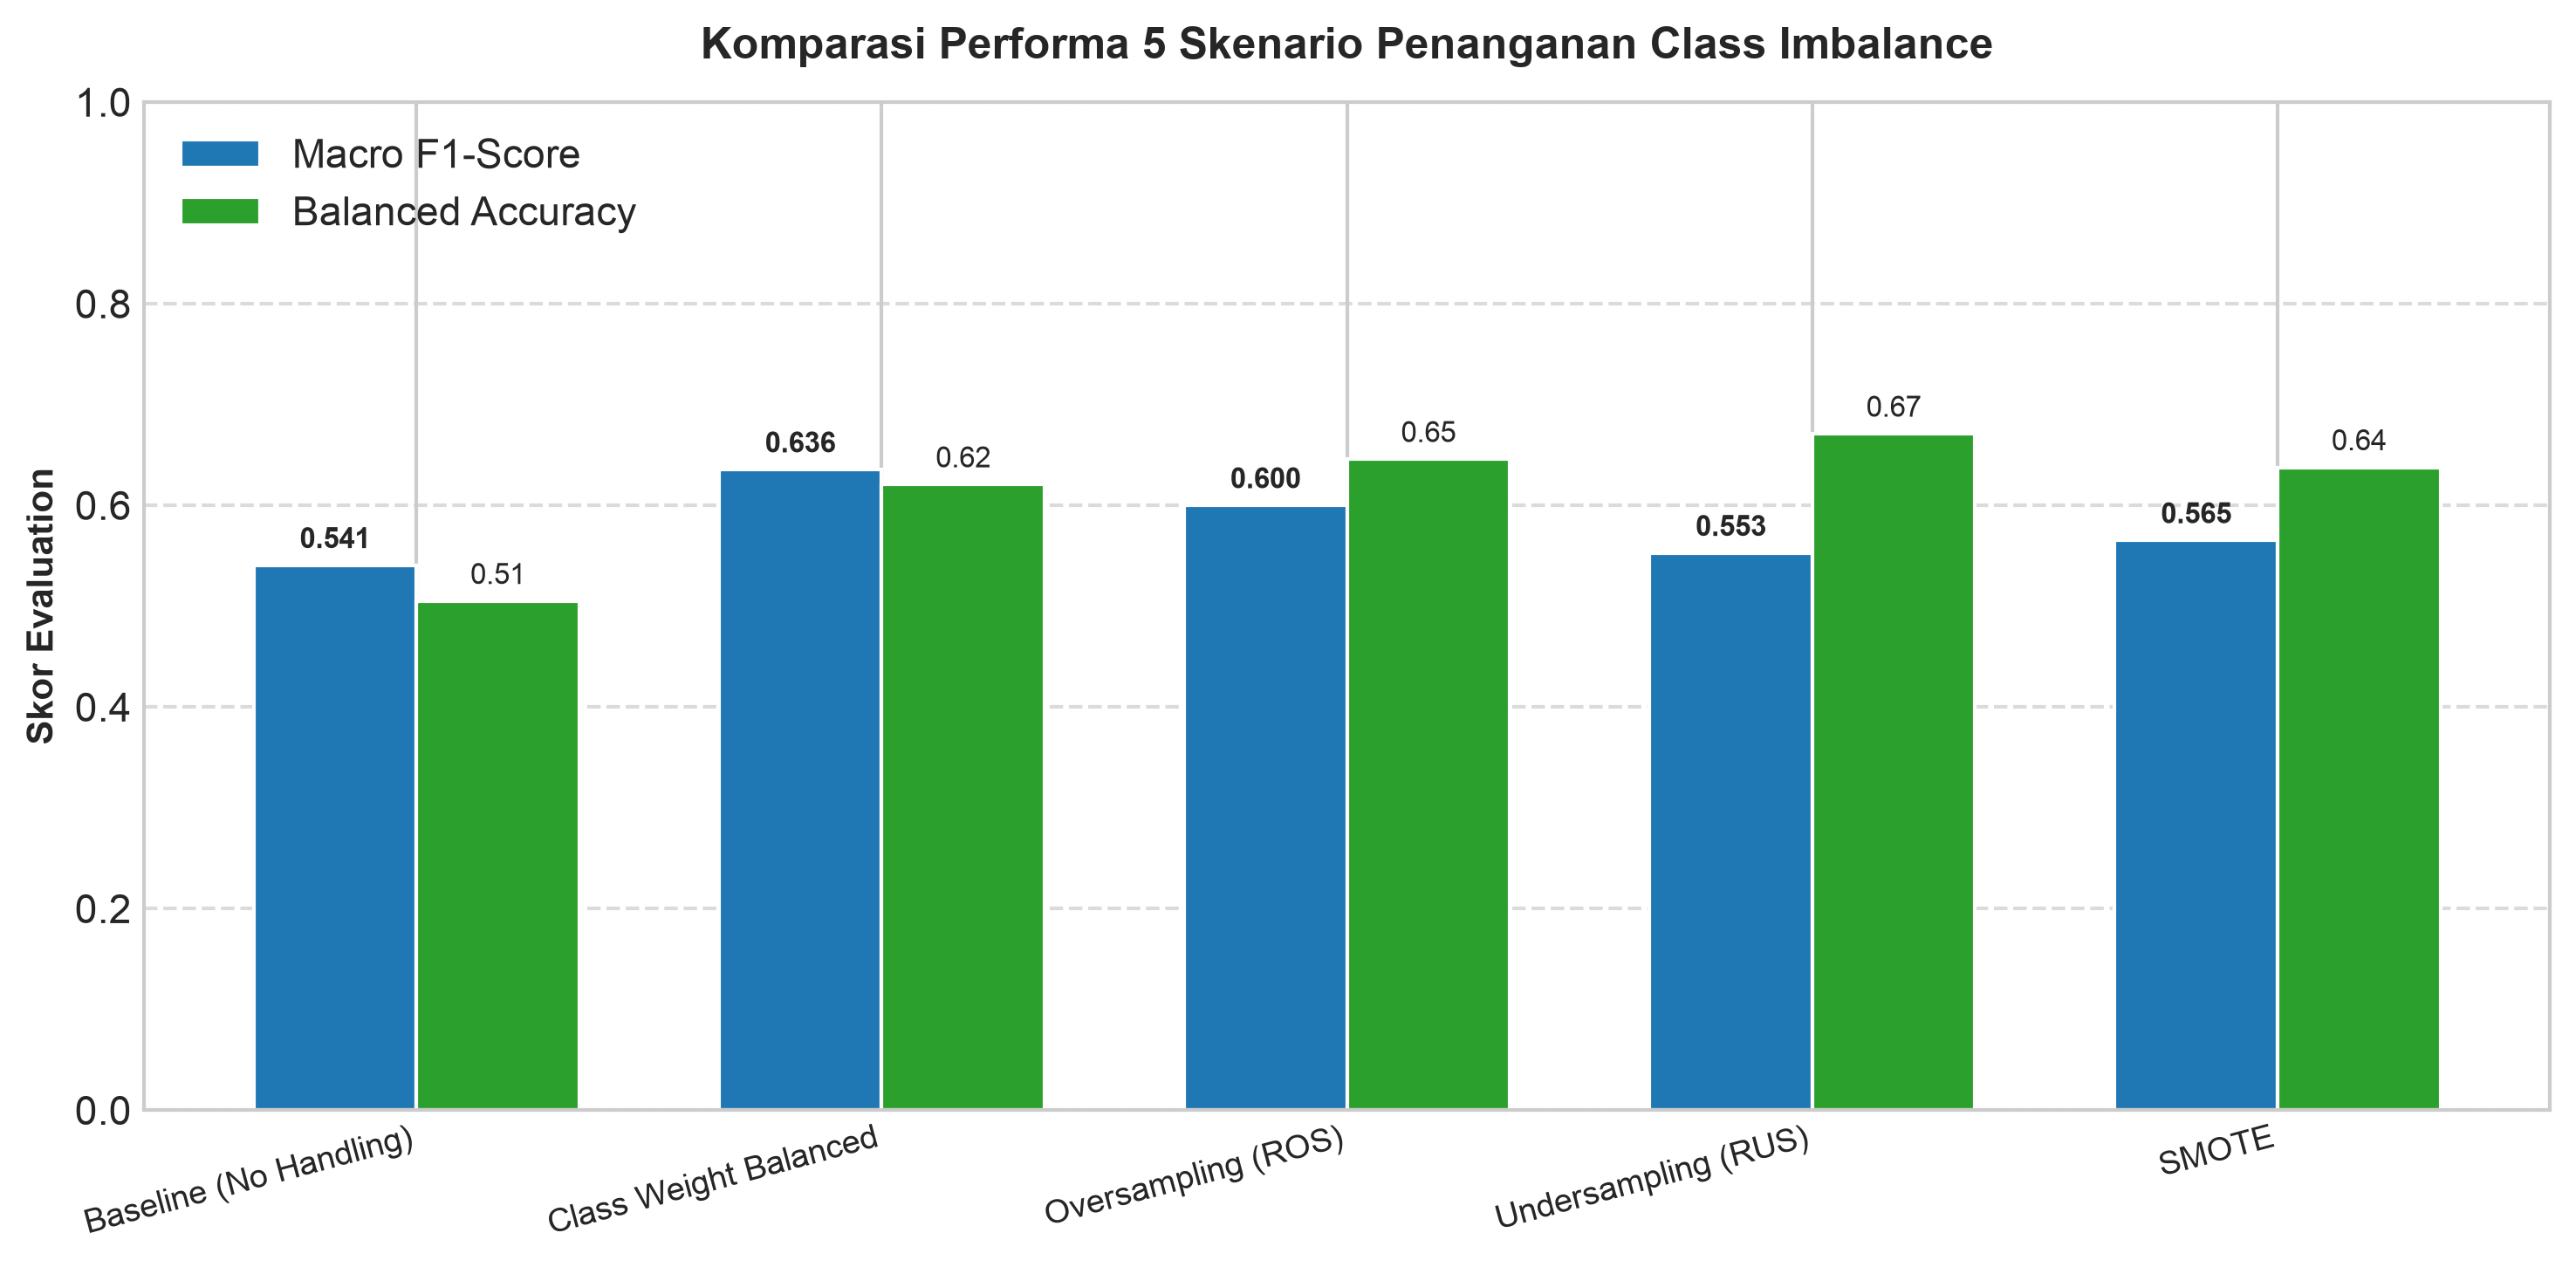

✅ Grafik komparasi disimpan ke: /Users/macbook/Garut-Tourism-Reccomendation/data/final/imbalance_experiments_comparison.png


In [19]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

x = np.arange(len(df_summary))
width = 0.35

macro_f1_vals = [r["raw_macro_f1"] for r in exp_results]
bal_acc_vals = [r["raw_bal_acc"] for r in exp_results]

rects1 = ax.bar(x - width/2, macro_f1_vals, width, label='Macro F1-Score', color='#1f77b4')
rects2 = ax.bar(x + width/2, bal_acc_vals, width, label='Balanced Accuracy', color='#2ca02c')

ax.set_ylabel('Skor Evaluation', fontsize=10, fontweight='bold')
ax.set_title('Komparasi Performa 5 Skenario Penanganan Class Imbalance', fontsize=12, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels([s.split('. ')[1] for s in df_summary["Skenario Eksperimen"]], rotation=15, ha='right', fontsize=9)
ax.set_ylim(0, 1.0)
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

for rect in rects1:
    h = rect.get_height()
    ax.annotate(f'{h:.3f}', xy=(rect.get_x() + rect.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8, fontweight='bold')

for rect in rects2:
    h = rect.get_height()
    ax.annotate(f'{h:.2f}', xy=(rect.get_x() + rect.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
img_path = settings.FINAL_DATA_DIR / "imbalance_experiments_comparison.png"
plt.savefig(img_path, bbox_inches="tight", dpi=300)
plt.show()
print(f"✅ Grafik komparasi disimpan ke: {img_path}")

Membuat visualisasi matriks konfusi (Confusion Matrix) berdampingan untuk seluruh 5 skenario eksperimen. Visualisasi ini mempermudah analisis pergeseran daya deteksi model terhadap kelas minoritas (Actual Netral dan Actual Negatif).

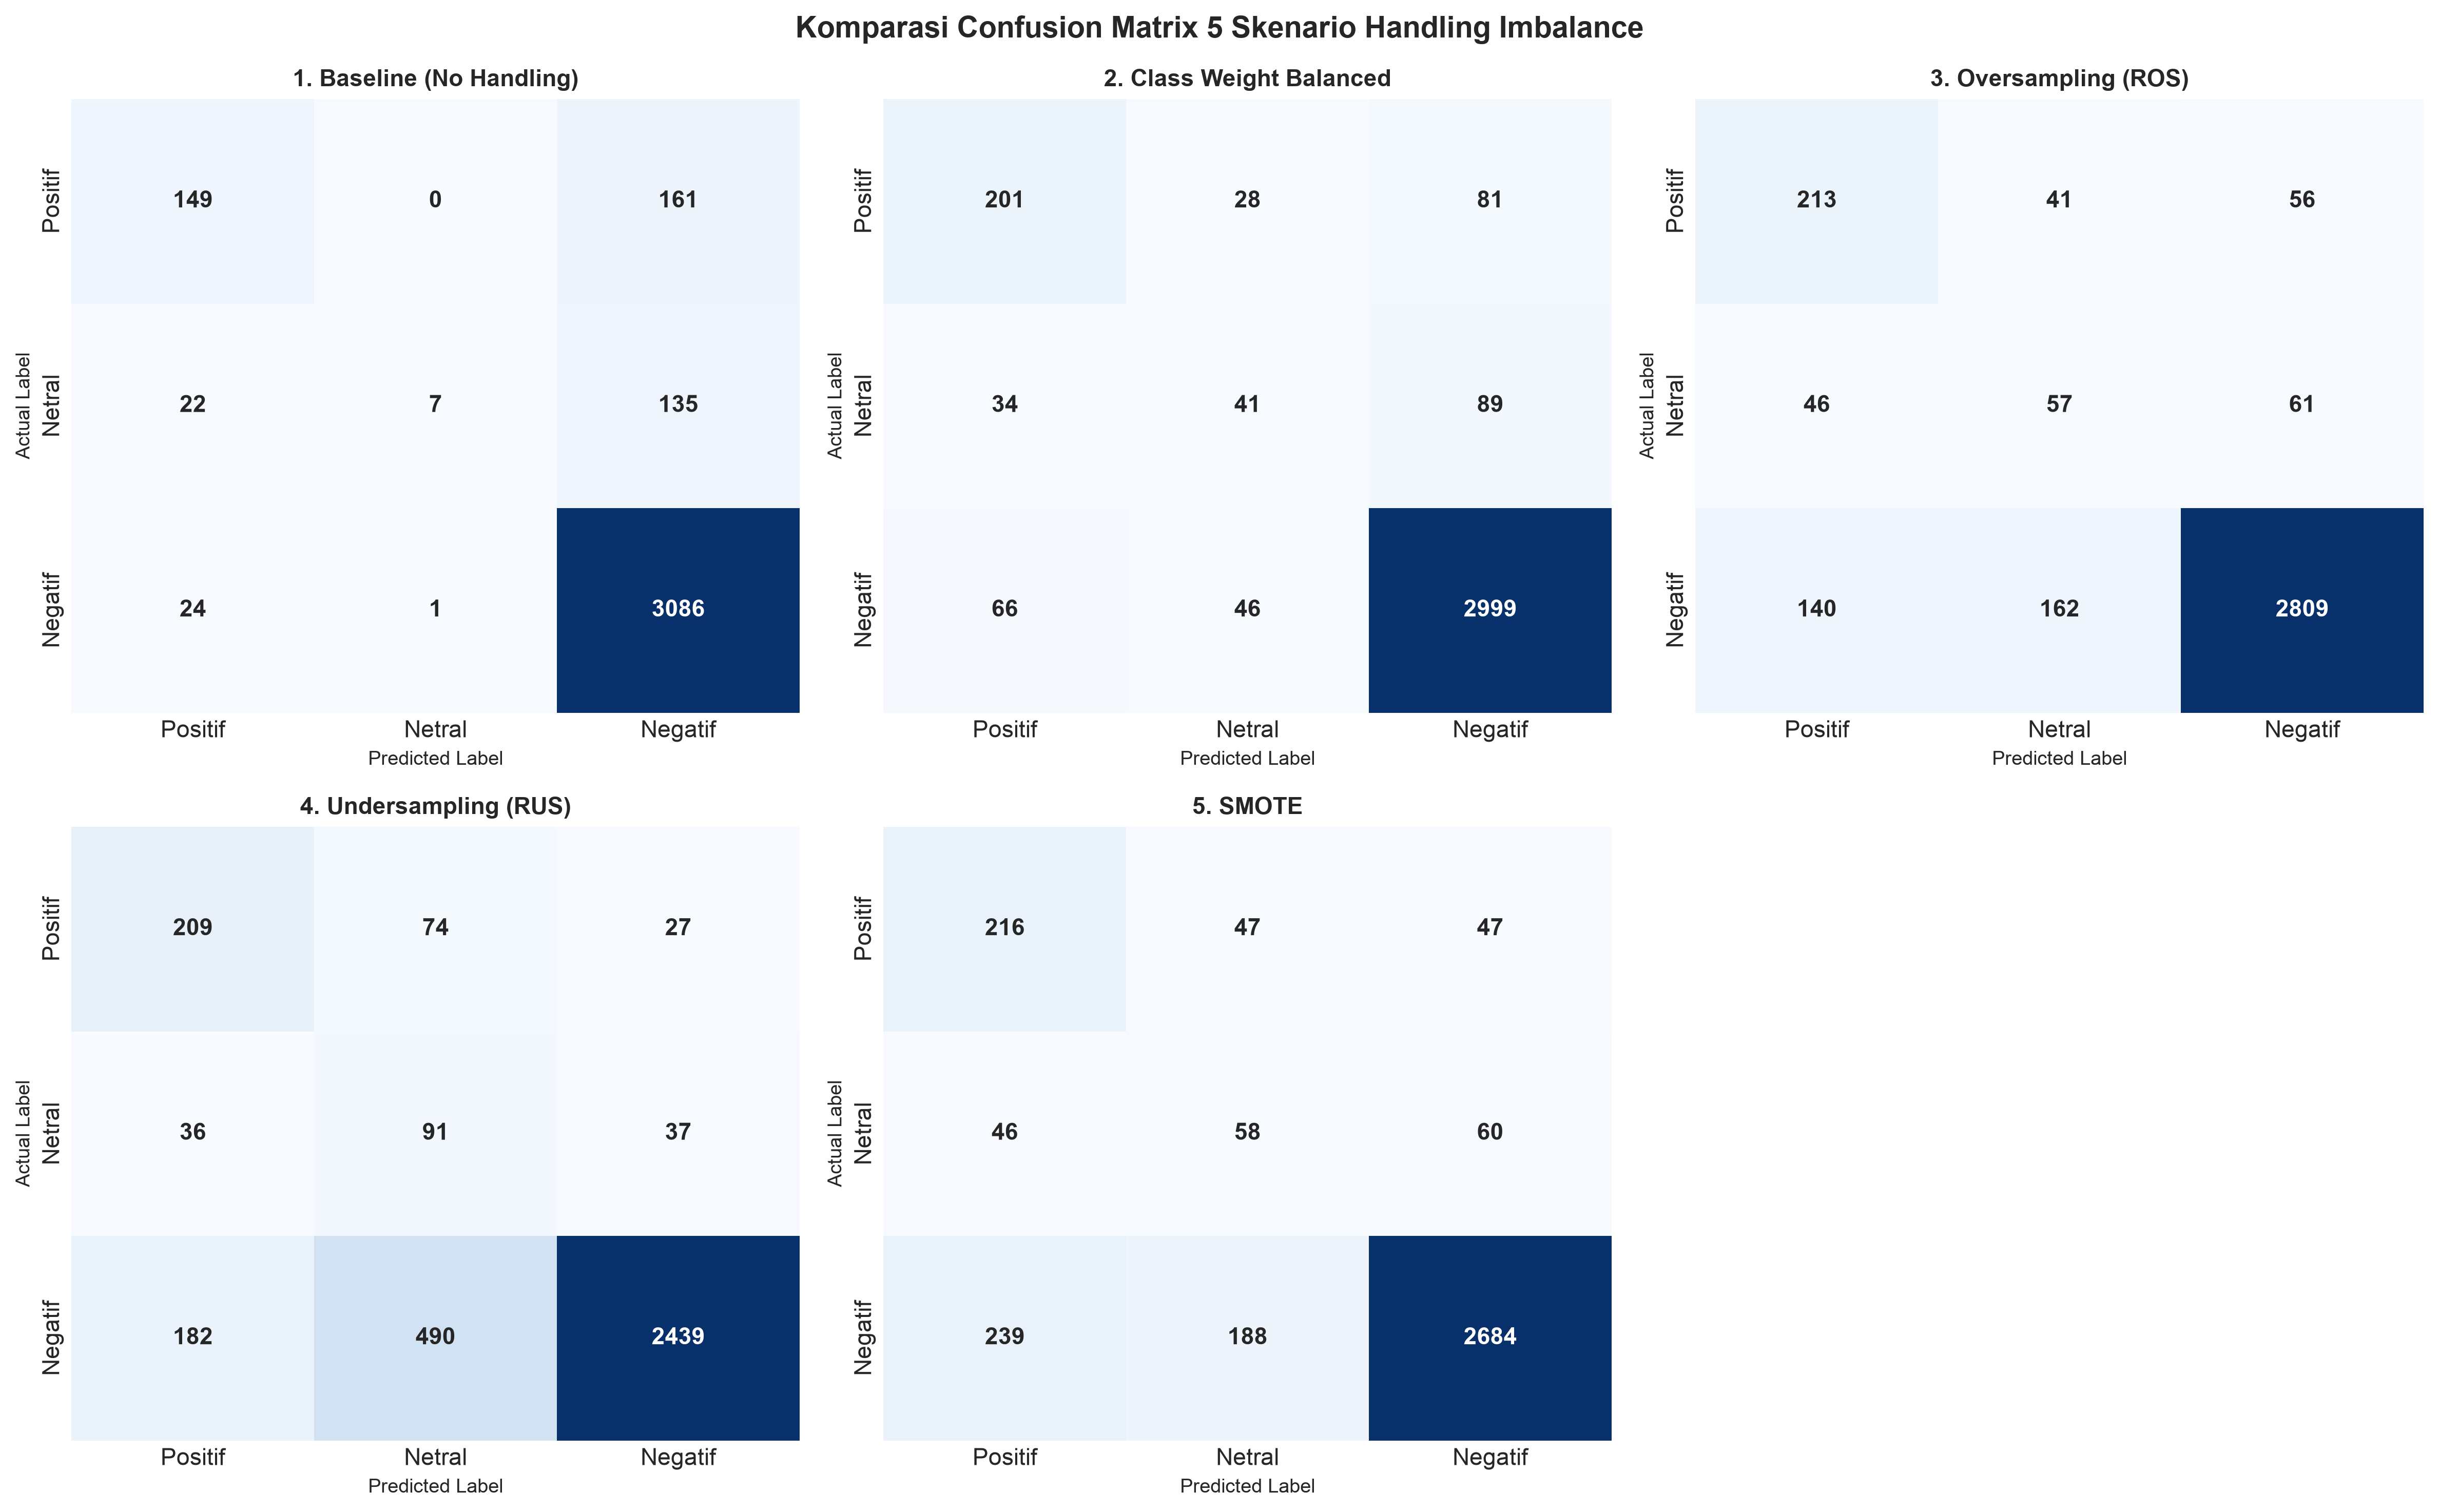

✅ Grid Confusion Matrix disimpan ke: /Users/macbook/Garut-Tourism-Reccomendation/data/final/all_scenarios_confusion_matrices.png


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=300)
axes = axes.flatten()
class_names = ["Positif", "Netral", "Negatif"]

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        ax=axes[idx], cbar=False, annot_kws={"size": 11, "weight": "bold"}
    )
    axes[idx].set_title(f"{name}", fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Predicted Label", fontsize=9)
    axes[idx].set_ylabel("Actual Label", fontsize=9)

# Hapus subplot kosong ke-6
fig.delaxes(axes[5])

plt.suptitle("Komparasi Confusion Matrix 5 Skenario Handling Imbalance", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()

cm_grid_path = settings.FINAL_DATA_DIR / "all_scenarios_confusion_matrices.png"
plt.savefig(cm_grid_path, bbox_inches="tight", dpi=300)
plt.show()
print(f"✅ Grid Confusion Matrix disimpan ke: {cm_grid_path}")

Menetapkan Skenario 2 (Class Weight Balanced) sebagai model utama penelitian berdasarkan pencapaian Macro F1-Score tertinggi (0,6356). Sel ini mencetak laporan klasifikasi rinci dan menyimpan artefak model (svm_model.joblib) serta pemroses TF-IDF (tfidf_vectorizer.joblib) untuk kebutuhan produksi pipeline dan antarmuka dashboard.

In [21]:
primary_model = trained_models["2. Class Weight Balanced"]
y_pred_primary = primary_model.predict(X_test_tfidf)

print("=== CLASSIFICATION REPORT MODEL TERPILIH (CLASS WEIGHT BALANCED) ===")
print(classification_report(
    y_test, 
    y_pred_primary, 
    target_names=["Positif (0)", "Netral (1)", "Negatif (2)"], 
    digits=4
))

# Save Serialized Model and Vectorizer Artifacts
settings.MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_path = settings.MODELS_DIR / "svm_model.joblib"
vec_path = settings.MODELS_DIR / "tfidf_vectorizer.joblib"

joblib.dump(primary_model, model_path)
joblib.dump(tfidf, vec_path)

print(f"✅ Artefak Model SVM berhasil disimpan ke: {model_path}")
print(f"✅ Artefak TF-IDF Vectorizer berhasil disimpan ke: {vec_path}")

=== CLASSIFICATION REPORT MODEL TERPILIH (CLASS WEIGHT BALANCED) ===
              precision    recall  f1-score   support

 Positif (0)     0.6678    0.6484    0.6579       310
  Netral (1)     0.3565    0.2500    0.2939       164
 Negatif (2)     0.9464    0.9640    0.9551      3111

    accuracy                         0.9040      3585
   macro avg     0.6569    0.6208    0.6356      3585
weighted avg     0.8953    0.9040    0.8992      3585

✅ Artefak Model SVM berhasil disimpan ke: /Users/macbook/Garut-Tourism-Reccomendation/models/svm_model.joblib
✅ Artefak TF-IDF Vectorizer berhasil disimpan ke: /Users/macbook/Garut-Tourism-Reccomendation/models/tfidf_vectorizer.joblib


Pada sel ini, dilakukan analisis interpretabilitas model (Explainable AI) dengan mengesktrak koefisien bobot (coefficients) tertinggi dari matriks Linear SVM untuk setiap kelas sentimen. Fitur kata dengan bobot koefisien positif tertinggi menunjukkan kata kunci paling berpengaruh dalam mendorong keputusan klasifikasi pada kelas tersebut.

=== TOP 10 FITUR KATA KUNCI PENENTU PER KELAS SENTIMEN ===


,Top Kata Positif (0),Bobot Koefisien Positif,Top Kata Netral (1),Bobot Koefisien Netral,Top Kata Negatif (2),Bobot Koefisien Negatif
0,kecewa,2.0835,krng,1.9659,luas,1.1810
1,keras,2.0235,okok,1.7000,enak,0.9711
2,pungli,1.9147,tolong,1.6340,keren,0.9467
3,mahal,1.7489,pasak,1.6293,cocok,0.8701
4,kapok,1.6844,pelihara,1.5356,adem,0.8125
5,kotor,1.5883,laut bagus,1.5297,lengkap,0.7561
6,jelek,1.4937,awat,1.5179,nyaman,0.7530
7,suruh,1.4697,laler,1.4539,best,0.7158
8,hambar,1.4631,jalan jelek,1.4263,enakk,0.7147
9,lambat,1.4579,okay,1.4047,wajib,0.6782


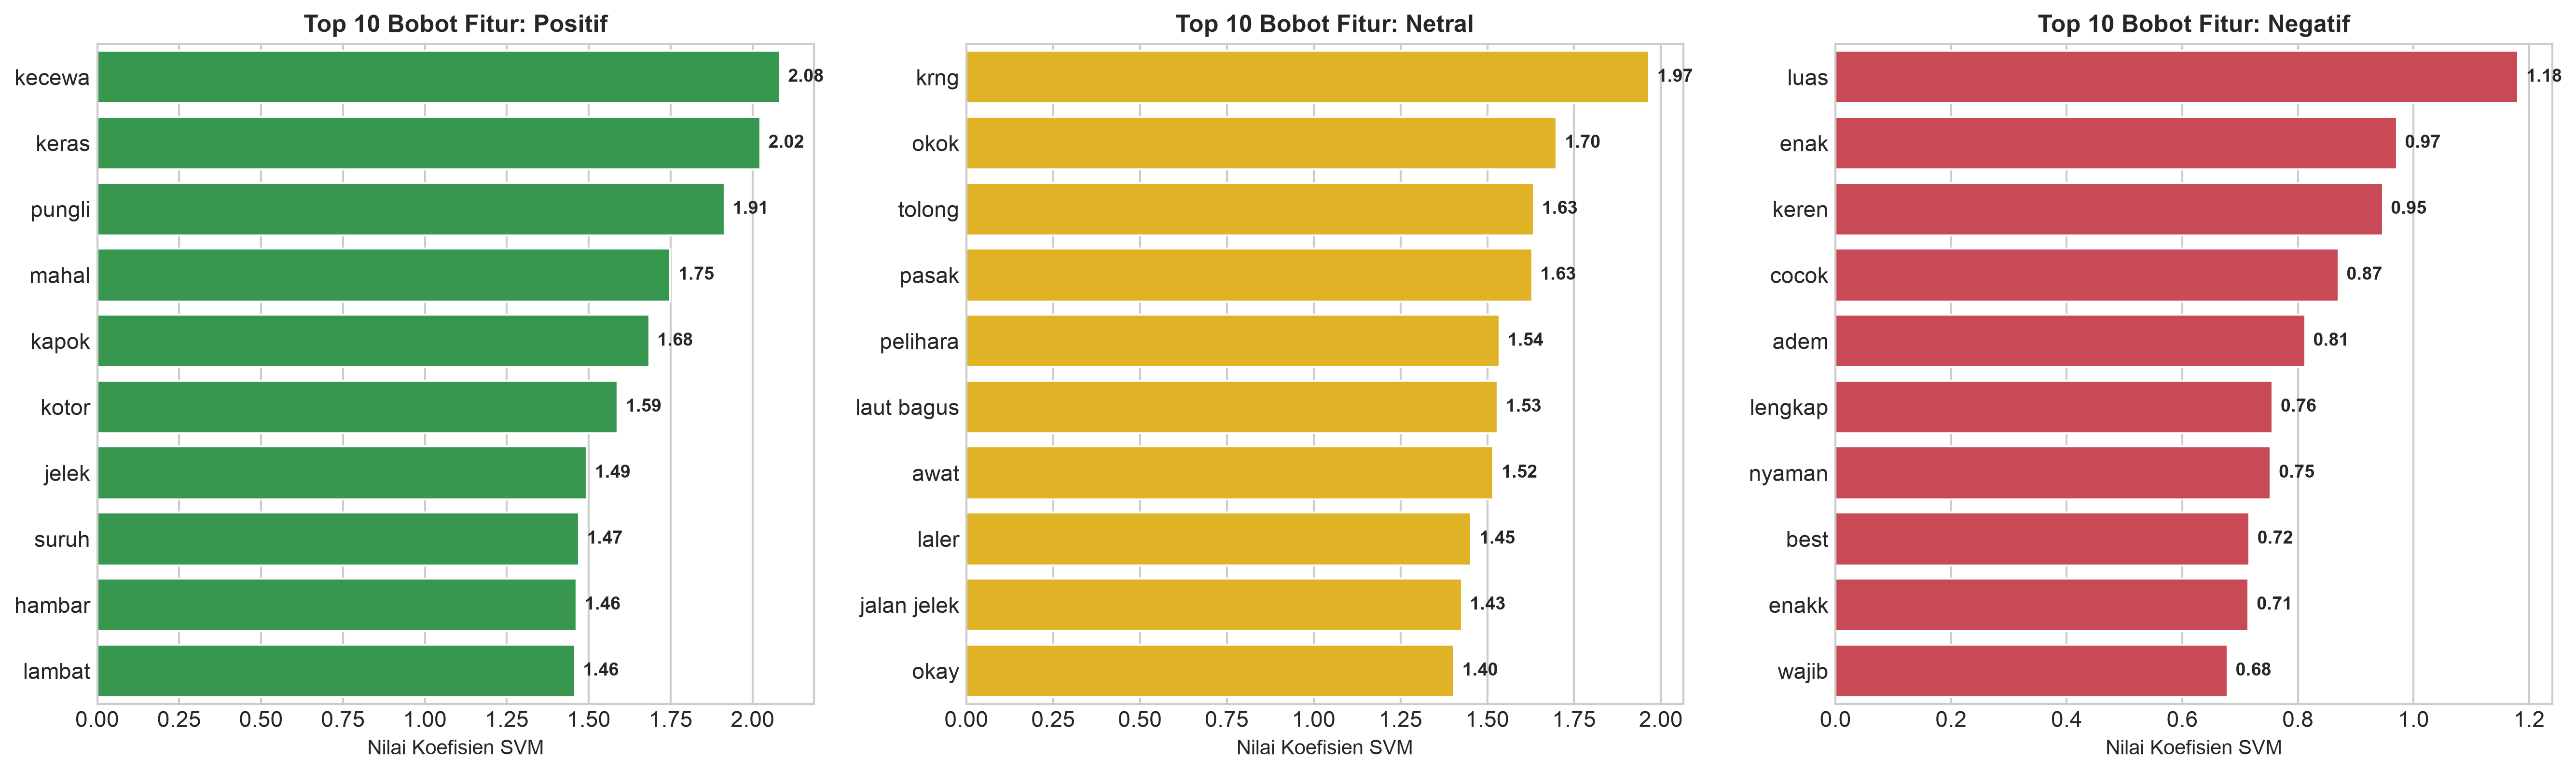

✅ Grafik bobot fitur berhasil disimpan ke: /Users/macbook/Garut-Tourism-Reccomendation/data/final/top_feature_coefficients.png


In [22]:
# Ekstraksi Kata Kunci Penentu per Kelas (Sesuai Mapping 0:Positif, 1:Netral, 2:Negatif)
feature_names = np.array(tfidf.get_feature_names_out())
coefs = primary_model.coef_

top_keywords_per_class = {}
configs_mapping = [
    (0, "Positif", "Greens_r", "#28a745"),
    (1, "Netral", "YlOrBr_r", "#ffc107"),
    (2, "Negatif", "Reds_r", "#dc3545")
]

for class_idx, class_name, _, _ in configs_mapping:
    top_pos_idx = np.argsort(coefs[class_idx])[-10:][::-1]
    top_keywords_per_class[f"Top Kata {class_name} ({class_idx})"] = feature_names[top_pos_idx]
    top_keywords_per_class[f"Bobot Koefisien {class_name}"] = [f"{coefs[class_idx][i]:.4f}" for i in top_pos_idx]

tabel_koefisien_svm = pd.DataFrame(top_keywords_per_class)
print("=== TOP 10 FITUR KATA KUNCI PENENTU PER KELAS SENTIMEN ===")
display(tabel_koefisien_svm)

# Visualisasi Bar Chart Koefisien Fitur Terpenting SVM
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=300)

for class_idx, name, palette, color in configs_mapping:
    top_idx = np.argsort(coefs[class_idx])[-10:][::-1]
    words = feature_names[top_idx]
    weights = coefs[class_idx][top_idx]
    
    sns.barplot(x=weights, y=words, ax=axes[class_idx], color=color)
    axes[class_idx].set_title(f"Top 10 Bobot Fitur: {name}", fontsize=12, fontweight="bold")
    axes[class_idx].set_xlabel("Nilai Koefisien SVM", fontsize=10)
    
    for p in axes[class_idx].patches:
        width = p.get_width()
        axes[class_idx].annotate(
            f'{width:.2f}', 
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', va='center', xytext=(4, 0), 
            textcoords='offset points', fontsize=9, fontweight="bold"
        )

plt.tight_layout()
coef_img_path = settings.FINAL_DATA_DIR / "top_feature_coefficients.png"
plt.savefig(coef_img_path, bbox_inches="tight", dpi=300)
plt.show()
print(f"✅ Grafik bobot fitur berhasil disimpan ke: {coef_img_path}")

### 📝 Kesimpulan Tahap Modeling & Eksperimen Imbalance Handling

1. **Pembagian Data & Pencegahan Leakage:**
   * Pembagian data dilakukan secara *stratified split* (80:20) menghasilkan **14.338 data latih** dan **3.585 data uji**.
   * Ekstraksi fitur TF-IDF (`ngram_range=(1,2)`, `max_features=10000`) dieksekusi secara ketat hanya pada data latih (*zero data leakage*).

2. **Hasil Komparasi 5 Skenario Handling Imbalance:**
   * **Baseline (No Handling):** Memiliki ketahanan buruk pada kelas minoritas (*Netral F1: 0,0800*).
   * **Class Weight Balanced:** Menghasilkan **Macro F1-Score tertinggi (0,6356)** dan terpilih sebagai model utama.
   * **Oversampling (ROS) & SMOTE:** Menunjukkan peningkatan performa (*Macro F1: 0,6001* dan *0,5676*), tetapi masih di bawah *Class Weight*.
   * **Undersampling (RUS):** Mencapai *Balanced Accuracy* tinggi (0,67), tetapi mengorbankan *Macro F1-Score* (0,5528) akibat pemotongan data latih mayoritas.

3. **Interpretabilitas Model Terpilih:**
   * Model Linear SVM dengan *Class Weight Balanced* terbukti secara empiris mempelajari bobot koefisien kata yang sangat representatif terhadap tiap kelas sentimen (misal: kata positif seperti *bagus, indah, mantap* dan kata negatif seperti *kotor, mahal, kecewa*).
   * Artefak model (`models/svm_model.joblib`) dan pemroses TF-IDF (`models/tfidf_vectorizer.joblib`) telah ter-serialisasi dan siap digunakan pada tahap evaluasi serta integrasi sistem.